<a href="https://colab.research.google.com/github/Alister44/DTA_2026_DE/blob/main/Unterrichtsaufgaben/pandas_matplotlib_combined.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐼 Pandas + 📊 Matplotlib: Datenanalyse von Grund auf

Dieses Notebook folgt dem Prinzip „gelernt — sofort gesehen“:
jede neue pandas-Technik wird sofort mit einem Diagramm untermauert.

**Matplotlib** ist hier wie eine Kamera: du lernst es nicht separat,
du machst einfach Schnappschüsse deiner Daten im richtigen Moment.

---
### So arbeitest du mit dem Notebook
- ▶️ **Shift+Enter** — Zelle ausführen und zur nächsten wechseln
- 📖 Textzellen — Theorie und Erklärungen
- 💻 Graue Zellen — Code, der ausgeführt werden muss
- 🎯 **Aufgabe** — löse sie selbst, Tipp darunter
- 💡 Zellen mit Tipps — nur öffnen, wenn du wirklich nicht weiterkommst
---



## Kapitel 0 — Vorbereitung: Bibliotheken importieren

Vor der Arbeit müssen wir die Bibliotheken „einbinden“.

```
pandas     → wir arbeiten mit Tabellen
matplotlib → wir zeichnen Diagramme
numpy      → numerische Operationen
```


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print(f'   pandas     {pd.__version__}')
print(f'   numpy      {np.__version__}')
print(f'   matplotlib {plt.matplotlib.__version__}')

   pandas     2.2.2
   numpy      2.0.2
   matplotlib 3.10.0


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

---
## Kapitel 1 — DataFrame: die Datentabelle

**DataFrame** ist eine Tabelle, wie in Excel. Zeilen sind Datensätze, Spalten sind Merkmale.

Stell dir vor, du hast eine Verkaufstabelle eines kleinen Cafés für eine Woche erhalten.
Laden wir sie manuell und schauen uns die Daten sofort an.


In [3]:
# Wir erstellen einen DataFrame aus einem Python-Dictionary
# Schlüssel des Dictionarys → Spaltennamen
# Listen → Werte in den Spalten

cafe = pd.DataFrame({
    'Tag':      ['Mo', 'Di', 'Mi', 'Do', 'Fr', 'Sa', 'So'],
    'Besucher': [87, 64, 95, 78, 142, 198, 173],
    'Umsatz':   [4350, 3200, 4750, 3900, 7100, 9900, 8650],
    'Wetter':   ['Sonnig', 'Regen', 'Bewölkt', 'Sonnig', 'Sonnig', 'Sonnig', 'Bewölkt']
})

# Einfach den Namen der Variable schreiben — pandas zeigt eine schöne Tabelle
cafe



,Tag,Besucher,Umsatz,Wetter
0,Mo,87,4350,Sonnig
1,Di,64,3200,Regen
2,Mi,95,4750,Bewölkt
3,Do,78,3900,Sonnig
4,Fr,142,7100,Sonnig
5,Sa,198,9900,Sonnig
6,So,173,8650,Bewölkt


Beachte: pandas hat automatisch einen **Index** (0, 1, 2...) hinzugefügt — die Zeilennummer.

Jetzt fragen wir pandas: „Was sind das überhaupt für Daten?“


In [4]:
print('Größe der Tabelle (Zeilen, Spalten):', cafe.shape)
print()
print('Datentypen in jeder Spalte:')
print(cafe.dtypes)


Größe der Tabelle (Zeilen, Spalten): (7, 4)

Datentypen in jeder Spalte:
Tag         object
Besucher     int64
Umsatz       int64
Wetter      object
dtype: object


In [5]:
# .describe() — sofortige Statistik zu den numerischen Spalten
cafe.describe().round(1)


,Besucher,Umsatz
count,7.0,7.0
mean,119.6,5978.6
std,51.6,2581.2
min,64.0,3200.0
25%,82.5,4125.0
50%,95.0,4750.0
75%,157.5,7875.0
max,198.0,9900.0


### 📊 Das erste Diagramm — direkt nach der ersten Tabelle

Pandas hat eine eingebaute Methode `.plot()` — sie ruft matplotlib für dich auf.
Die Formel ist einfach:
```python
df.plot(x='Spalte_für_X_Achse', y='Spalte_für_Y_Achse', kind='Diagrammtyp')
plt.show()
```
Typen: `line`, `bar`, `barh`, `hist`, `scatter`, `pie`


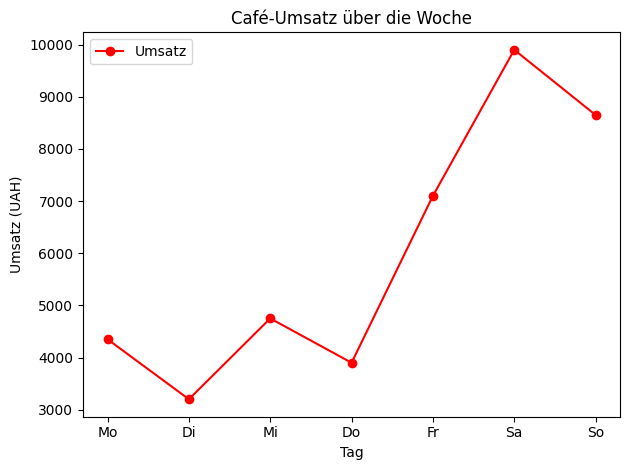

In [6]:
# Liniendiagramm des Umsatzes nach Tagen
cafe.plot(
    x='Tag', y='Umsatz',
    kind='line',
    marker='o',
    color='red',
    title='Café-Umsatz über die Woche',
    ylabel='Umsatz (UAH)',
    legend=True
)
plt.tight_layout()
plt.show()


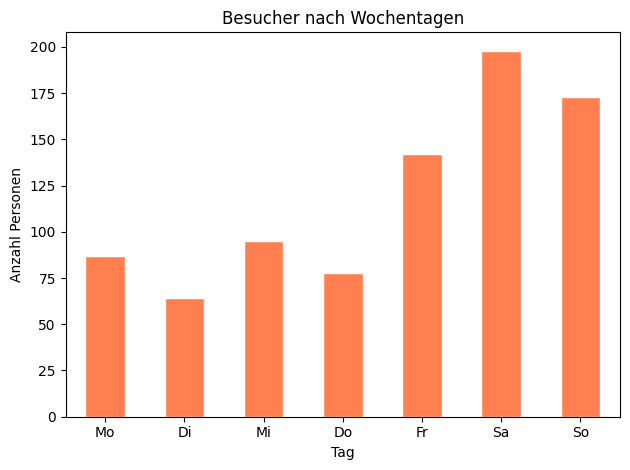

In [7]:
# Balkendiagramm — besser für den Vergleich nach Kategorien
cafe.plot(
    x='Tag', y='Besucher',
    kind='bar',
    color='coral',
    edgecolor='white',
    title='Besucher nach Wochentagen',
    ylabel='Anzahl Personen',
    legend=False,
    rot=0
)
plt.tight_layout()
plt.show()


### 🎯 Aufgabe 1.1

Erstelle einen DataFrame mit Temperaturdaten für 5 Städte:

| Stadt | Temperatur | Luftfeuchtigkeit_% | Niederschlag_mm |
|-------|-------------|-------------|----------|
| Kyiv | 18 | 72 | 5 |
| Harkiv | 21 | 65 | 0 |
| Odesa | 24 | 80 | 0 |
| Lviv | 15 | 78 | 12 |
| Dnipro | 22 | 60 | 0 |

Dann:
1. Gib die Tabelle und `.describe()` aus
2. Erstelle ein **horizontales** Balkendiagramm (`kind='barh'`) der Temperatur nach Städten


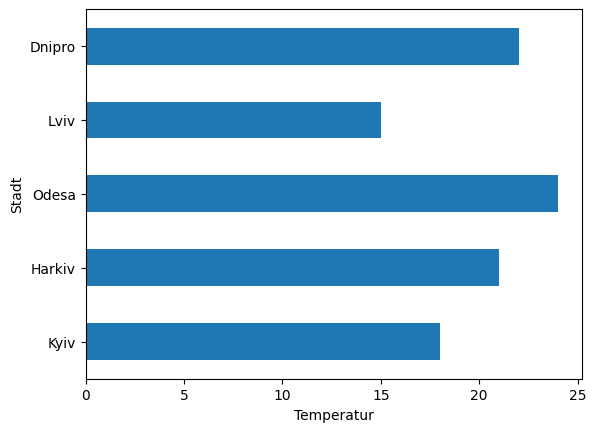

In [8]:
weather = pd.DataFrame({
    'Stadt':       ['Kyiv','Harkiv','Odesa','Lviv','Dnipro'],
    'Temperatur':  [18, 21, 24, 15, 22],
    'Luftfeuchtigkeit_%': [72, 65, 80, 78, 60],
    'Niederschlag_mm':    [5, 0, 0, 12, 0]
})

weather.plot(
    x='Stadt',
    y='Temperatur',
    kind='barh',
    legend=False,
    xlabel='Temperatur'
)

plt.show()


In [9]:
# 💡 Tipp:
print("""
weather = pd.DataFrame({
    'Stadt':       ['Kyiv','Harkiv','Odesa','Lviv','Dnipro'],
    'Temperatur':  [18, 21, 24, 15, 22],
    'Luftfeuchtigkeit_%': [72, 65, 80, 78, 60],
    'Niederschlag_mm':    [5, 0, 0, 12, 0]
})
print(weather)
print(weather.describe().round(1))

weather.plot(x='Stadt', y='Temperatur', kind='barh',
             color='tomato', title='Temperatur nach Städten',
             xlabel='°C', legend=False)
plt.tight_layout()
plt.show()
""")



weather = pd.DataFrame({
    'Stadt':       ['Kyiv','Harkiv','Odesa','Lviv','Dnipro'],
    'Temperatur':  [18, 21, 24, 15, 22],
    'Luftfeuchtigkeit_%': [72, 65, 80, 78, 60],
    'Niederschlag_mm':    [5, 0, 0, 12, 0]
})
print(weather)
print(weather.describe().round(1))

weather.plot(x='Stadt', y='Temperatur', kind='barh',
             color='tomato', title='Temperatur nach Städten',
             xlabel='°C', legend=False)
plt.tight_layout()
plt.show()



---
## Kapitel 2 — Datenauswahl: Spalten und Zeilen

Die meiste Zeit arbeitet ein Analyst nicht mit der ganzen Tabelle, sondern mit Teilen davon.
Lernen wir, das Nötige „herauszuholen“.

Für dieses Kapitel laden wir einen größeren Datensatz — Daten eines Online-Shops.


In [10]:
# Wir erzeugen einen realistischen Datensatz von Bestellungen
np.random.seed(42)
n = 120

shop = pd.DataFrame({
    'Bestell_ID': range(1001, 1001 + n),
    'Kunde':      np.random.choice(['Olena K.','Maksym R.','Anja S.','Bohdan V.',
                                    'Katja M.','Ihor L.','Sofia D.','Taras N.'], n),
    'Kategorie':  np.random.choice(['Elektronik','Kleidung','Bücher','Sport','Haus'], n,
                                   p=[0.25, 0.30, 0.15, 0.15, 0.15]),
    'Stadt':      np.random.choice(['Kyiv','Harkiv','Odesa','Lviv','Dnipro'], n,
                                   p=[0.35, 0.20, 0.15, 0.20, 0.10]),
    'Betrag':     (np.random.exponential(600, n) + 150).round(0).astype(int),
    'Menge':      np.random.randint(1, 6, n),
    'Lieferung':  np.random.choice(['Nova Poshta','Ukrposhta','Kurier'], n,
                                   p=[0.55, 0.25, 0.20])
})

print(f'Größe: {shop.shape[0]} Bestellungen, {shop.shape[1]} Spalten')
shop.head(6)


Größe: 120 Bestellungen, 7 Spalten


,Bestell_ID,Kunde,Kategorie,Stadt,Betrag,Menge,Lieferung
0,1001,Sofia D.,Kleidung,Kyiv,182,1,Ukrposhta
1,1002,Bohdan V.,Kleidung,Kyiv,605,5,Ukrposhta
2,1003,Katja M.,Sport,Dnipro,617,5,Nova Poshta
3,1004,Sofia D.,Kleidung,Lviv,759,2,Kurier
4,1005,Anja S.,Kleidung,Kyiv,927,2,Kurier
5,1006,Taras N.,Kleidung,Odesa,2384,2,Nova Poshta


### Spalten auswählen


In [11]:
# Eine Spalte → Series (wie eine Liste mit Index)
print('Typ einer einzelnen Spalte:', type(shop['Betrag']))
print()
print(shop['Betrag'].head(5))


Typ einer einzelnen Spalte: <class 'pandas.core.series.Series'>

0    182
1    605
2    617
3    759
4    927
Name: Betrag, dtype: int64


In [12]:
# Mehrere Spalten → DataFrame (doppelte Klammern!)
shop[['Kunde', 'Kategorie', 'Betrag']].head(6)


,Kunde,Kategorie,Betrag
0,Sofia D.,Kleidung,182
1,Bohdan V.,Kleidung,605
2,Katja M.,Sport,617
3,Sofia D.,Kleidung,759
4,Anja S.,Kleidung,927
5,Taras N.,Kleidung,2384


### Zeilen auswählen: `.iloc` und `.loc`

| Methode | Logik | Beispiel |
|-------|--------|---------|
| `.iloc[i]` | Nach der **Position** der Zeile (wie in einer Liste) | `df.iloc[0]` — erste Zeile |
| `.loc[i]`  | Nach der **Index-Bezeichnung** | `df.loc[0]` — Zeile mit Index 0 |


In [13]:
# .iloc — nach Position
print('Erste Zeile (iloc[0]):')
print(shop.iloc[0])
print("-"*10)
print('Zeilen 2-4, Spalten 0-2:')
print(shop.iloc[2:5, 0:3])


Erste Zeile (iloc[0]):
Bestell_ID         1001
Kunde          Sofia D.
Kategorie      Kleidung
Stadt              Kyiv
Betrag              182
Menge                 1
Lieferung     Ukrposhta
Name: 0, dtype: object
----------
Zeilen 2-4, Spalten 0-2:
   Bestell_ID     Kunde Kategorie
2        1003  Katja M.     Sport
3        1004  Sofia D.  Kleidung
4        1005   Anja S.  Kleidung


### Zeilen filtern — die wichtigste Operation!

Prinzip: innerhalb von `df[...]` schreiben wir eine **Bedingung**, und pandas behält nur die Zeilen, bei denen sie True ist.


In [14]:
# Bestellungen mit einem Betrag über 1000 UAH
big_orders = shop[shop['Betrag'] > 1000]
print(f'Große Bestellungen: {len(big_orders)} von {len(shop)}')
big_orders[['Bestell_ID','Kunde','Kategorie','Betrag']].head(5)


Große Bestellungen: 27 von 120


,Bestell_ID,Kunde,Kategorie,Betrag
5,1006,Taras N.,Kleidung,2384
8,1009,Sofia D.,Elektronik,1101
13,1014,Anja S.,Sport,2122
14,1015,Taras N.,Sport,1235
24,1025,Bohdan V.,Kleidung,2009


In [15]:
# Komplexe Bedingungen: & (und), | (oder)
# WICHTIG: jede Bedingung in Klammern!

# Elektronik aus Kyjiw
kyiv_electronics = shop[(shop['Stadt'] == 'Kyiv') & (shop['Kategorie'] == 'Elektronik')]
print(f'Elektronik aus Kyjiw: {len(kyiv_electronics)} Bestellungen')

# Teure Bestellungen oder Bücher
premium_or_books = shop[(shop['Betrag'] > 2000) | (shop['Kategorie'] == 'Bücher')]
print(f'Teuer oder Bücher:    {len(premium_or_books)} Bestellungen')


Elektronik aus Kyjiw: 6 Bestellungen
Teuer oder Bücher:    18 Bestellungen


In [16]:
# .isin() — Prüfung, ob ein Wert in einer Liste enthalten ist
western = shop[shop['Stadt'].isin(['Kyiv', 'Lviv'])]
print(f'Kyjiw oder Lwiw: {len(western)} Bestellungen')

# .between() — Bereich
mid_range = shop[shop['Betrag'].between(500, 1500)]
print(f'Betrag 500-1500 UAH: {len(mid_range)} Bestellungen')


Kyjiw oder Lwiw: 67 Bestellungen
Betrag 500-1500 UAH: 53 Bestellungen


### 📊 Histogramm — der erste Blick auf die Verteilung numerischer Daten

Bevor du Zahlen analysierst — schau dir an, **wie sie verteilt sind**.


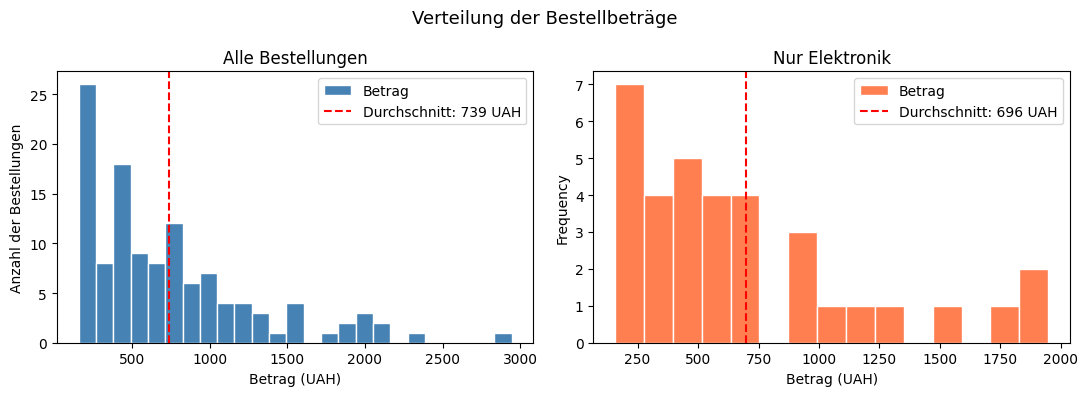

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
# 1 - komplettes Diagramm
# 2 - Achsen
# figsize=(11, 4) 11 - Breite, 4 - Höhe
# Verteilung der Beträge ALLER Bestellungen
shop['Betrag'].plot.hist(ax=axes[0], bins=25, color='steelblue',
                       edgecolor='white', title='Alle Bestellungen')
axes[0].set_xlabel('Betrag (UAH)')
axes[0].set_ylabel('Anzahl der Bestellungen')
axes[0].axvline(shop['Betrag'].mean(), color='red', linestyle='--',
                label=f"Durchschnitt: {shop['Betrag'].mean():.0f} UAH")
axes[0].legend()

# Verteilung nur für Elektronik
elec = shop[shop['Kategorie'] == 'Elektronik']['Betrag']
elec.plot.hist(ax=axes[1], bins=15, color='coral',
               edgecolor='white', title='Nur Elektronik')
axes[1].set_xlabel('Betrag (UAH)')
axes[1].axvline(elec.mean(), color='red', linestyle='--',
                label=f'Durchschnitt: {elec.mean():.0f} UAH')
axes[1].legend()

plt.suptitle('Verteilung der Bestellbeträge', fontsize=13)
plt.tight_layout()
plt.show()


### 🎯 Aufgabe 2.1

Verwende den Datensatz `shop`:
1. Gib alle Bestellungen aus Harkiv aus
2. Finde Bestellungen, bei denen die Menge >= 4 und der Betrag < 500 UAH ist
3. Erstelle ein Histogramm der Bestellbeträge **nur für Harkiv** (vergleiche mit dem Gesamtbild)


In [18]:
# Dein Code hier:




In [19]:
# 💡 Tipp:
print("""
# 1.
kharkiv = shop[shop['Stadt'] == 'Harkiv']
print(kharkiv)

# 2.
odd = shop[(shop['Menge'] >= 4) & (shop['Betrag'] < 500)]
print(odd)

# 3.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
shop['Betrag'].plot.hist(ax=axes[0], bins=20, color='steelblue',
                       edgecolor='white', title='Alle Städte')
kharkiv['Betrag'].plot.hist(ax=axes[1], bins=15, color='darkorange',
                          edgecolor='white', title='Nur Harkiv')
plt.tight_layout()
plt.show()
""")



# 1.
kharkiv = shop[shop['Stadt'] == 'Harkiv']
print(kharkiv)

# 2.
odd = shop[(shop['Menge'] >= 4) & (shop['Betrag'] < 500)]
print(odd)

# 3.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
shop['Betrag'].plot.hist(ax=axes[0], bins=20, color='steelblue',
                       edgecolor='white', title='Alle Städte')
kharkiv['Betrag'].plot.hist(ax=axes[1], bins=15, color='darkorange',
                          edgecolor='white', title='Nur Harkiv')
plt.tight_layout()
plt.show()



---
## Kapitel 3 — Neue Spalten und Transformationen

Rohdaten enthalten selten alles Nötige. Ein Analyst **erstellt neue Merkmale** aus vorhandenen.


In [20]:
s = shop.copy()

# 1. Einfache berechnete Spalte
s['Preis_pro_Einheit'] = (s['Betrag'] / s['Menge']).round(0).astype(int)

# 2. Bedingte Spalte über np.where (wie IF in Excel)
# np.where(Bedingung, wenn_True, wenn_False)
s['Rabatt'] = np.where(s['Betrag'] > 1000, (s['Betrag'] * 0.95).round(0), s['Betrag']).astype(int)

# 3. Mehrere Bedingungsebenen (verschachteltes np.where)
s['Segment'] = np.where(s['Betrag'] >= 1500, 'Groß',
               np.where(s['Betrag'] >= 600,  'Mittel', 'Klein'))

s[['Bestell_ID','Betrag','Menge','Preis_pro_Einheit','Segment']].head(8)


,Bestell_ID,Betrag,Menge,Preis_pro_Einheit,Segment
0,1001,182,1,182,Klein
1,1002,605,5,121,Mittel
2,1003,617,5,123,Mittel
3,1004,759,2,380,Mittel
4,1005,927,2,464,Mittel
5,1006,2384,2,1192,Groß
6,1007,586,5,117,Klein
7,1008,384,3,128,Klein


In [21]:
# pd.cut — automatische Aufteilung in Bereiche
s['Betrag_Gruppe'] = pd.cut(
    s['Betrag'],
    bins=[0, 300, 700, 1500, 99999],
    labels=['bis 300', '300-700', '700-1500', '1500+']
)

print(s['Betrag_Gruppe'].value_counts().sort_index())


Betrag_Gruppe
bis 300     27
300-700     42
700-1500    37
1500+       14
Name: count, dtype: int64


### 📊 Scatter Plot — Zusammenhang zwischen zwei numerischen Variablen

Scatter (Streudiagramm) zeigt, ob zwei numerische Kennzahlen miteinander zusammenhängen.


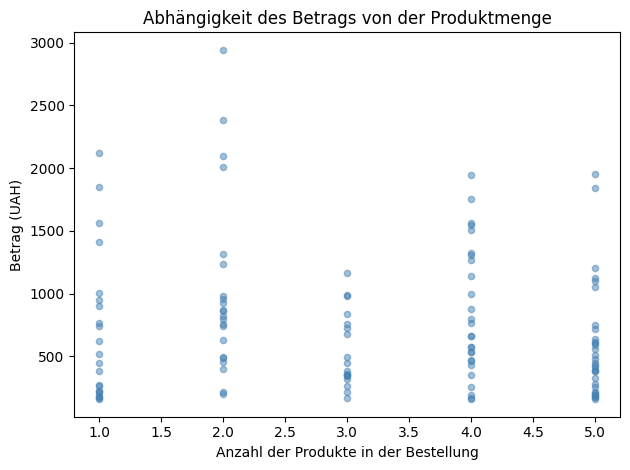

Korrelation: -0.107  (0 = kein Zusammenhang, 1 = positiv, -1 = negativ)


In [22]:
# Gibt es einen Zusammenhang zwischen Menge und Bestellbetrag?
shop.plot.scatter(
    x='Menge', y='Betrag',
    alpha=0.5,
    color='steelblue',
    title="Abhängigkeit des Betrags von der Produktmenge",
    xlabel='Anzahl der Produkte in der Bestellung',
    ylabel='Betrag (UAH)'
)
plt.tight_layout()
plt.show()

corr = shop['Menge'].corr(shop['Betrag'])
print(f"Korrelation: {corr:.3f}  (0 = kein Zusammenhang, 1 = positiv, -1 = negativ)")


### 🎯 Aufgabe 3.1

Im Datensatz `shop`:
1. Füge die Spalte `'Umsatz_pro_Einheit'` hinzu = Betrag / Menge (auf ganze Zahlen runden)
2. Füge die Spalte `'VIP'` hinzu: True wenn Betrag > 1500, sonst False
3. Erstelle einen Scatter Plot: X-Achse = Menge, Y-Achse = Umsatz_pro_Einheit. Gibt es ein Muster?


In [23]:
# Dein Code hier:




In [24]:
# 💡 Tipp:
print("""
s2 = shop.copy()
s2['Umsatz_pro_Einheit'] = (s2['Betrag'] / s2['Menge']).round(0).astype(int)
s2['VIP'] = s2['Betrag'] > 1500

print(s2[['Betrag','Menge','Umsatz_pro_Einheit','VIP']].head(8))
print('VIP-Bestellungen:', s2['VIP'].sum())

s2.plot.scatter(x='Menge', y='Umsatz_pro_Einheit',
                alpha=0.5, color='purple',
                title='Umsatz pro Einheit vs Menge')
plt.tight_layout()
plt.show()
""")



s2 = shop.copy()
s2['Umsatz_pro_Einheit'] = (s2['Betrag'] / s2['Menge']).round(0).astype(int)
s2['VIP'] = s2['Betrag'] > 1500

print(s2[['Betrag','Menge','Umsatz_pro_Einheit','VIP']].head(8))
print('VIP-Bestellungen:', s2['VIP'].sum())

s2.plot.scatter(x='Menge', y='Umsatz_pro_Einheit',
                alpha=0.5, color='purple',
                title='Umsatz pro Einheit vs Menge')
plt.tight_layout()
plt.show()



---
## Kapitel 4 — Gruppieren: groupby

`groupby` ist das Analogon zur Pivot-Tabelle in Excel.
Die Logik ist immer dieselbe:

```python
df.groupby('Gruppierungsfeld')['Wertefeld'].Funktion()
#      ↑                            ↑               ↑
#  wonach gruppieren          was berechnen    sum/mean/max/count
```


In [25]:
# Gesamtumsatz nach Kategorien
by_category = shop.groupby('Kategorie')['Betrag'].sum().sort_values(ascending=False)
print(by_category)


Kategorie
Kleidung      29943
Elektronik    23671
Sport         14451
Haus          12566
Bücher         8060
Name: Betrag, dtype: int64


In [26]:
# .agg() — mehrere Funktionen auf einmal
category_stats = shop.groupby('Kategorie').agg(
    Bestellungen = ('Betrag', 'count'),
    Betrag_gesamt = ('Betrag', 'sum'),
    Betrag_avg   = ('Betrag', 'mean'),
    Betrag_max   = ('Betrag', 'max')
).round(0).astype(int)


category_stats


,Bestellungen,Betrag_gesamt,Betrag_avg,Betrag_max
Kategorie,,,,
Bücher,13,8060,620,1547
Elektronik,34,23671,696,1948
Haus,15,12566,838,2944
Kleidung,38,29943,788,2384
Sport,20,14451,723,2122


In [27]:
category_stats = shop.groupby('Kategorie')['Betrag'].agg(['count','sum','mean','max']).round(0).astype(int)
category_stats


,count,sum,mean,max
Kategorie,,,,
Bücher,13,8060,620,1547
Elektronik,34,23671,696,1948
Haus,15,12566,838,2944
Kleidung,38,29943,788,2384
Sport,20,14451,723,2122


In [28]:
# Gruppierung nach zwei Feldern + unstack = Pivot-Tabelle
city_cat = shop.groupby(['Stadt', 'Kategorie'])['Betrag'].sum().unstack(fill_value=0)
city_cat


Kategorie,Bücher,Elektronik,Haus,Kleidung,Sport
Stadt,,,,,
Dnipro,0,446,2333,4899,1062
Harkiv,572,7674,400,2347,2534
Kyiv,3998,7757,1814,10725,4902
Lviv,1681,5581,3711,6038,1637
Odesa,1809,2213,4308,5934,4316


### 📊 Balkendiagramm nach groupby — die häufigste Kombination

Das Ergebnis von `groupby` sind bereits fertige Daten für ein Diagramm.


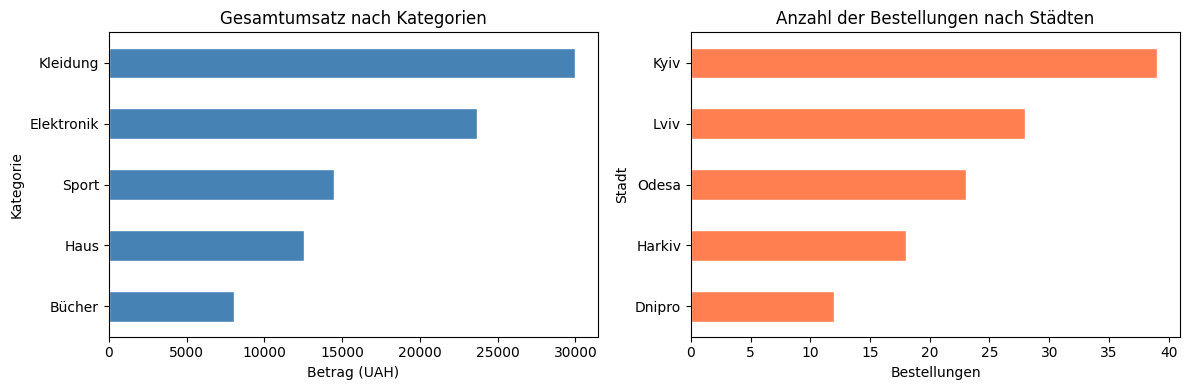

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Umsatz nach Kategorien
by_cat = shop.groupby('Kategorie')['Betrag'].sum().sort_values()
by_cat.plot.barh(ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Gesamtumsatz nach Kategorien')
axes[0].set_xlabel('Betrag (UAH)')

# Anzahl der Bestellungen nach Städten
by_city = shop.groupby('Stadt')['Bestell_ID'].count().sort_values()
by_city.plot.barh(ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Anzahl der Bestellungen nach Städten')
axes[1].set_xlabel('Bestellungen')

plt.tight_layout()
plt.show()


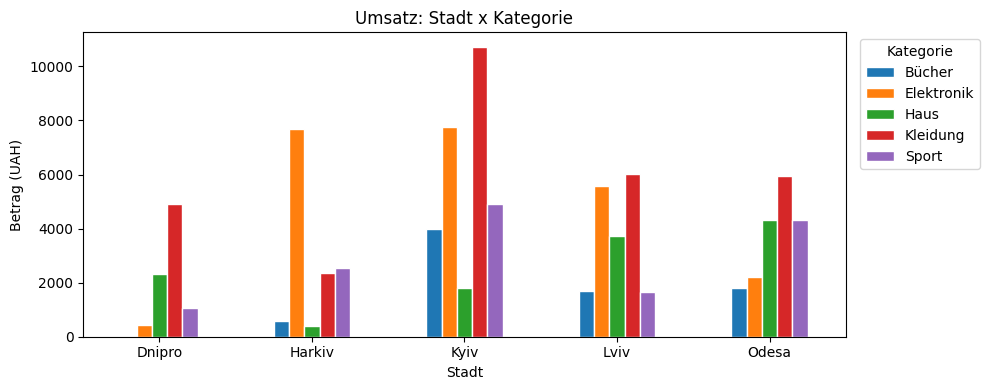

In [30]:
# Gruppiertes Balkendiagramm: mehrere Datenreihen
city_cat.plot.bar(
    figsize=(10, 4),
    edgecolor='white',
    title='Umsatz: Stadt x Kategorie',
    ylabel='Betrag (UAH)',
    rot=0
)
plt.legend(title='Kategorie', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()


### 🎯 Aufgabe 4.1

Verwende `shop`:
1. Finde den durchschnittlichen Bestellbetrag für jede Stadt (absteigend sortiert)
2. Finde die Anzahl der Bestellungen für jede Versandart
3. Erstelle **zwei** Diagramme auf einer Leinwand: durchschnittlicher Betrag nach Städten und Anzahl nach Versandart


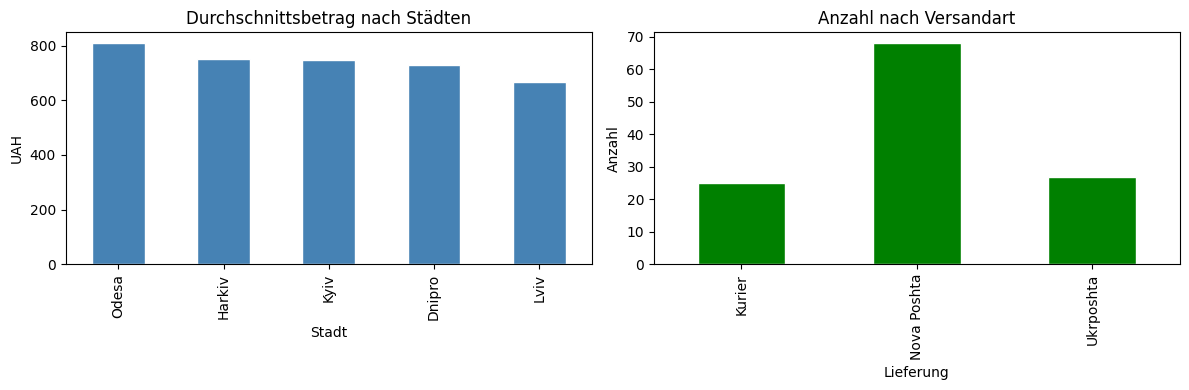

In [31]:
avg_by_city = shop.groupby('Stadt')['Betrag'].mean().sort_values(ascending=False).round(1)
count_by_delivery_method = shop.groupby('Lieferung')['Bestell_ID'].count()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

avg_by_city.plot.bar(ax=axes[0], color='steelblue', edgecolor='white',
                     title='Durchschnittsbetrag nach Städten', ylabel='UAH')
count_by_delivery_method.plot.bar(ax=axes[1], color='green', edgecolor='white',
                                  title='Anzahl nach Versandart', ylabel='Anzahl')

plt.tight_layout()
plt.show()



In [32]:
# 💡 Tipp:
print("""
avg_city     = shop.groupby('Stadt')['Betrag'].mean().sort_values(ascending=False).round(0)
delivery_cnt = shop.groupby('Lieferung')['Bestell_ID'].count()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

avg_city.plot.bar(ax=axes[0], color='steelblue', edgecolor='white', rot=30,
                  title='Durchschnittsbetrag nach Städten', ylabel='UAH')

delivery_cnt.plot.bar(ax=axes[1], color='mediumseagreen', edgecolor='white', rot=15,
                      title='Bestellungen nach Versandart', ylabel='Anzahl')

plt.tight_layout()
plt.show()
""")



avg_city     = shop.groupby('Stadt')['Betrag'].mean().sort_values(ascending=False).round(0)
delivery_cnt = shop.groupby('Lieferung')['Bestell_ID'].count()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

avg_city.plot.bar(ax=axes[0], color='steelblue', edgecolor='white', rot=30,
                  title='Durchschnittsbetrag nach Städten', ylabel='UAH')

delivery_cnt.plot.bar(ax=axes[1], color='mediumseagreen', edgecolor='white', rot=15,
                      title='Bestellungen nach Versandart', ylabel='Anzahl')

plt.tight_layout()
plt.show()



---
## Kapitel 5 — Sortieren und Top-N finden

Eine häufige Aufgabe für Analysten: „Wer ist in den Top-5?“, „Was ist das Schlechteste?“, „Sortiere nach zwei Feldern.“


In [33]:
print('Top-5 größte Bestellungen:')
shop.sort_values('Betrag', ascending=False)[['Bestell_ID','Kunde','Kategorie','Betrag']].head(5)


Top-5 größte Bestellungen:


,Bestell_ID,Kunde,Kategorie,Betrag
90,1091,Taras N.,Haus,2944
5,1006,Taras N.,Kleidung,2384
13,1014,Anja S.,Sport,2122
66,1067,Bohdan V.,Sport,2099
24,1025,Bohdan V.,Kleidung,2009


In [34]:
# nlargest / nsmallest — praktische Abkürzung für Top-N
print('Top-3 Bestellungen:')
print(shop.nlargest(3, 'Betrag')[['Kunde','Kategorie','Stadt','Betrag']])

print()
print('3 kleinste:')
print(shop.nsmallest(3, 'Betrag')[['Kunde','Kategorie','Stadt','Betrag']])


Top-3 Bestellungen:
       Kunde Kategorie  Stadt  Betrag
90  Taras N.      Haus   Lviv    2944
5   Taras N.  Kleidung  Odesa    2384
13   Anja S.     Sport  Odesa    2122

3 kleinste:
         Kunde   Kategorie   Stadt  Betrag
107  Bohdan V.  Elektronik  Harkiv     157
32   Bohdan V.       Sport   Odesa     159
71   Maksym R.  Elektronik  Harkiv     161


In [35]:
# value_counts — Häufigkeit jedes Werts zählen
print('Häufigkeit der Kategorien:')
print(shop['Kategorie'].value_counts())
print()
print('In Prozent:')
print((shop['Kategorie'].value_counts(normalize=True) * 100).round(1))


Häufigkeit der Kategorien:
Kategorie
Kleidung      38
Elektronik    34
Sport         20
Haus          15
Bücher        13
Name: count, dtype: int64

In Prozent:
Kategorie
Kleidung      31.7
Elektronik    28.3
Sport         16.7
Haus          12.5
Bücher        10.8
Name: proportion, dtype: float64


### 📊 Kreisdiagramm — Anteile am Ganzen

> 💡 **Wann Pie und wann Bar?** Pie — wenn du Anteile zeigen willst (max. ~5 Segmente). Bar — wenn du Werte vergleichst. Analysten bevorzugen meist Bar — es ist präziser.


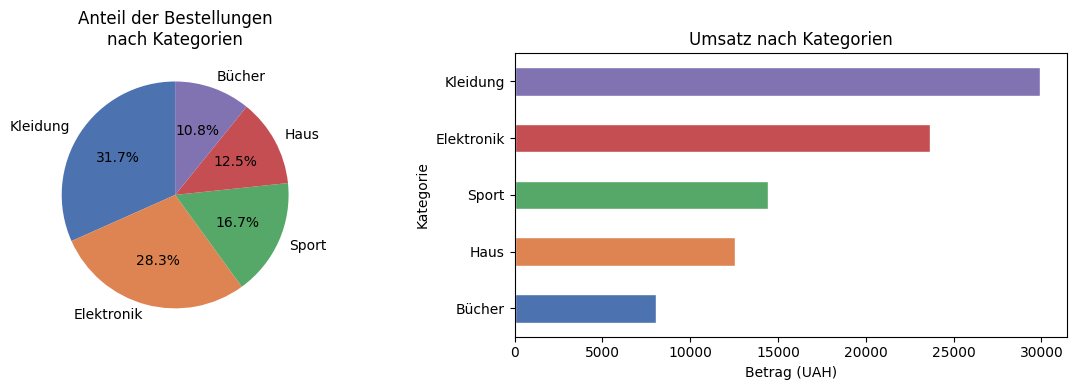

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Kreisdiagramm
shop['Kategorie'].value_counts().plot.pie(
    ax=axes[0],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2'],
    title='Anteil der Bestellungen\nnach Kategorien'
)
axes[0].set_ylabel('')

# Bar — präziser für den Vergleich
shop.groupby('Kategorie')['Betrag'].sum().sort_values().plot.barh(
    ax=axes[1],
    color=['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2'],
    edgecolor='white',
    title='Umsatz nach Kategorien'
)
axes[1].set_xlabel('Betrag (UAH)')

plt.tight_layout()
plt.show()


### 🎯 Aufgabe 5.1

1. Finde die Top-3-Kunden nach der Gesamtsumme all ihrer Bestellungen
2. Berechne die Anzahl der Bestellungen für jede Stadt und stelle sie in einem Kreisdiagramm dar
3. Gib die 3 kleinsten Bestellungen aus der Kategorie „Bücher“ aus


In [37]:
# Dein Code hier:




In [38]:
# 💡 Tipp:
print("""
top_clients = shop.groupby('Kunde')['Betrag'].sum().nlargest(3)
print(top_clients)

shop['Stadt'].value_counts().plot.pie(
    autopct='%1.0f%%', startangle=90, title='Bestellungen nach Städten'
)
plt.ylabel('')
plt.tight_layout()
plt.show()

books = shop[shop['Kategorie'] == 'Bücher']
print(books.nsmallest(3, 'Betrag')[['Kunde','Stadt','Betrag']])
""")



top_clients = shop.groupby('Kunde')['Betrag'].sum().nlargest(3)
print(top_clients)

shop['Stadt'].value_counts().plot.pie(
    autopct='%1.0f%%', startangle=90, title='Bestellungen nach Städten'
)
plt.ylabel('')
plt.tight_layout()
plt.show()

books = shop[shop['Kategorie'] == 'Bücher']
print(books.nsmallest(3, 'Betrag')[['Kunde','Stadt','Betrag']])



---
## Kapitel 6 — Fehlende Werte

Echte Daten sind immer „schmutzig“ — sie enthalten Lücken, Fehler, Duplikate.

`NaN` (Not a Number) — die Kennzeichnung eines fehlenden Werts in pandas.


In [39]:
raw = pd.DataFrame({
    'Produkt':    ['Laptop','Telefon','Tablet','Uhr','Kopfhörer','Maus','Tastatur'],
    'Kategorie':  ['Technik','Technik', None,    'Zubehör','Zubehör', None, 'Zubehör'],
    'Preis':      [25000,    None,      9500,    4200,       None,        850,   1200],
    'Lager':      [12,       5,         None,    8,          20,          None,  15],
    'Bewertung':  [4.5,      4.8,       4.2,     None,       4.6,         4.1,   None]
})

print('Daten:')
display(raw)
print('Fehlende Werte pro Spalte:')
print(raw.isnull().sum())


Daten:


,Produkt,Kategorie,Preis,Lager,Bewertung
0,Laptop,Technik,25000.0,12.0,4.5
1,Telefon,Technik,NaN,5.0,4.8
2,Tablet,None,9500.0,NaN,4.2
3,Uhr,Zubehör,4200.0,8.0,NaN
4,Kopfhörer,Zubehör,NaN,20.0,4.6
5,Maus,None,850.0,NaN,4.1
6,Tastatur,Zubehör,1200.0,15.0,NaN


Fehlende Werte pro Spalte:
Produkt      0
Kategorie    2
Preis        2
Lager        2
Bewertung    2
dtype: int64


In [40]:
clean = raw.copy()

# Numerisch → mit Mittelwert oder Median ersetzen
clean['Preis']     = clean['Preis'].fillna(clean['Preis'].median())
clean['Lager']     = clean['Lager'].fillna(0)
clean['Bewertung'] = clean['Bewertung'].fillna(round(clean['Bewertung'].mean(), 1))

# Text → mit einer Konstante ersetzen
clean['Kategorie'] = clean['Kategorie'].fillna('Unbekannt')

print('Nach der Bereinigung:')
display(clean)
print(f'Verbleibende fehlende Werte: {clean.isnull().sum().sum()}')


Nach der Bereinigung:


,Produkt,Kategorie,Preis,Lager,Bewertung
0,Laptop,Technik,25000.0,12.0,4.5
1,Telefon,Technik,4200.0,5.0,4.8
2,Tablet,Unbekannt,9500.0,0.0,4.2
3,Uhr,Zubehör,4200.0,8.0,4.4
4,Kopfhörer,Zubehör,4200.0,20.0,4.6
5,Maus,Unbekannt,850.0,0.0,4.1
6,Tastatur,Zubehör,1200.0,15.0,4.4


Verbleibende fehlende Werte: 0


### 📊 Prozentsatz fehlender Werte — die „Verschmutzung“ der Daten visualisieren


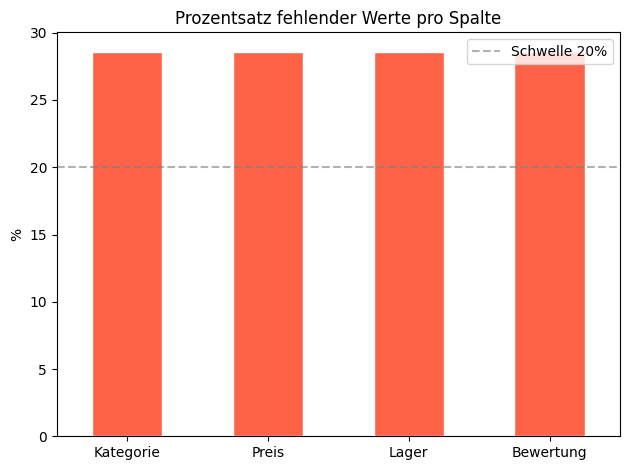

In [41]:
missing_pct = (raw.isnull().sum() / len(raw) * 100).round(1)
missing_pct_nz = missing_pct[missing_pct > 0]

missing_pct_nz.plot.bar(
    color='tomato', edgecolor='white', rot=0,
    title='Prozentsatz fehlender Werte pro Spalte',
    ylabel='%'
)
plt.axhline(20, color='gray', linestyle='--', alpha=0.6, label='Schwelle 20%')
plt.legend()
plt.tight_layout()
plt.show()


### 🎯 Aufgabe 6.1

Es gibt Wetterüberwachungsdaten von Stationen. Bereinige den Datensatz:
1. Gib die Anzahl und den Prozentsatz der fehlenden Werte für jede Spalte aus
2. Fülle `Temperatur` mit dem Median, `Wind_ms` mit Null, `Stadt` mit „Unbekannt“
3. Erstelle ein Balkendiagramm des Prozentsatzes fehlender Werte **vor** der Bereinigung


In [42]:
stations = pd.DataFrame({
    'Station':       ['S01','S02','S03','S04','S05','S06','S07','S08'],
    'Stadt':         ['Kyiv', None, 'Harkiv', 'Odesa', None, 'Lviv', 'Dnipro', None],
    'Temperatur':    [-3, -5, None, 4, -1, None, 2, -2],
    'Luftfeuchtigkeit': [72, 68, 75, 80, None, 65, None, 70],
    'Wind_ms':       [5, None, 3, 8, 6, None, 4, 7]
})

print('Vor der Bereinigung:')
display(stations)

# Dein Code hier:



Vor der Bereinigung:


,Station,Stadt,Temperatur,Luftfeuchtigkeit,Wind_ms
0,S01,Kyiv,-3.0,72.0,5.0
1,S02,None,-5.0,68.0,NaN
2,S03,Harkiv,NaN,75.0,3.0
3,S04,Odesa,4.0,80.0,8.0
4,S05,None,-1.0,NaN,6.0
5,S06,Lviv,NaN,65.0,NaN
6,S07,Dnipro,2.0,NaN,4.0
7,S08,None,-2.0,70.0,7.0


In [43]:
# 💡 Tipp:
print("""
missing = (stations.isnull().sum() / len(stations) * 100).round(1)
print(missing)

missing[missing > 0].plot.bar(color='tomato', edgecolor='white', rot=0,
                               title='Fehlende Werte vor der Bereinigung', ylabel='%')
plt.tight_layout()
plt.show()

st = stations.copy()
st['Temperatur'] = st['Temperatur'].fillna(st['Temperatur'].median())
st['Wind_ms']    = st['Wind_ms'].fillna(0)
st['Stadt']      = st['Stadt'].fillna('Unbekannt')
display(st)
""")



missing = (stations.isnull().sum() / len(stations) * 100).round(1)
print(missing)

missing[missing > 0].plot.bar(color='tomato', edgecolor='white', rot=0,
                               title='Fehlende Werte vor der Bereinigung', ylabel='%')
plt.tight_layout()
plt.show()

st = stations.copy()
st['Temperatur'] = st['Temperatur'].fillna(st['Temperatur'].median())
st['Wind_ms']    = st['Wind_ms'].fillna(0)
st['Stadt']      = st['Stadt'].fillna('Unbekannt')
display(st)



---
## Kapitel 7 — Zeitreihen: Datumsangaben in pandas

Sehr oft sind Daten zeitgebunden: Verkäufe nach Tagen, Temperatur nach Stunden usw.


In [44]:
np.random.seed(7)
dates = pd.date_range(start='2024-01-01', end='2024-06-30', freq='D')

trend    = np.linspace(800, 1400, len(dates))
seasonal = 200 * np.sin(np.linspace(0, 4 * np.pi, len(dates)))
noise    = np.random.normal(0, 120, len(dates))
weekend  = np.array([300 if d.weekday() >= 5 else 0 for d in dates])

ts = pd.DataFrame({
    'Datum':    dates,
    'Verkäufe': (trend + seasonal + noise + weekend).clip(200).round(0).astype(int)
}).set_index('Datum')

print(f'Größe: {ts.shape}')
ts.head(7)


Größe: (182, 1)


,Verkäufe
Datum,
2024-01-01,1003
2024-01-02,761
2024-01-03,838
2024-01-04,900
2024-01-05,773
2024-01-06,1185
2024-01-07,1201


In [45]:
# Wir extrahieren Teile des Datums
ts_ext = ts.copy()
ts_ext['Monat']     = ts_ext.index.month
ts_ext['Wochentag'] = ts_ext.index.dayofweek  # 0=Mo, 6=So
ts_ext['Wochenende'] = ts_ext['Wochentag'] >= 5

ts_ext.head(8)


,Verkäufe,Monat,Wochentag,Wochenende
Datum,,,,
2024-01-01,1003,1,0,False
2024-01-02,761,1,1,False
2024-01-03,838,1,2,False
2024-01-04,900,1,3,False
2024-01-05,773,1,4,False
2024-01-06,1185,1,5,True
2024-01-07,1201,1,6,True
2024-01-08,706,1,0,False


In [46]:
# resample — Aggregation nach Zeitfenster
# 'W' = Woche, 'ME' = Monatsende
weekly  = ts.resample('W')['Verkäufe'].sum()
monthly = ts.resample('ME')['Verkäufe'].sum()

print('Nach Monaten:')
print(monthly)


Nach Monaten:
Datum
2024-01-31    32765
2024-02-29    30068
2024-03-31    31221
2024-04-30    41698
2024-05-31    39577
2024-06-30    39844
Freq: ME, Name: Verkäufe, dtype: int64


### 📊 Zeitreihe — Liniendiagramm


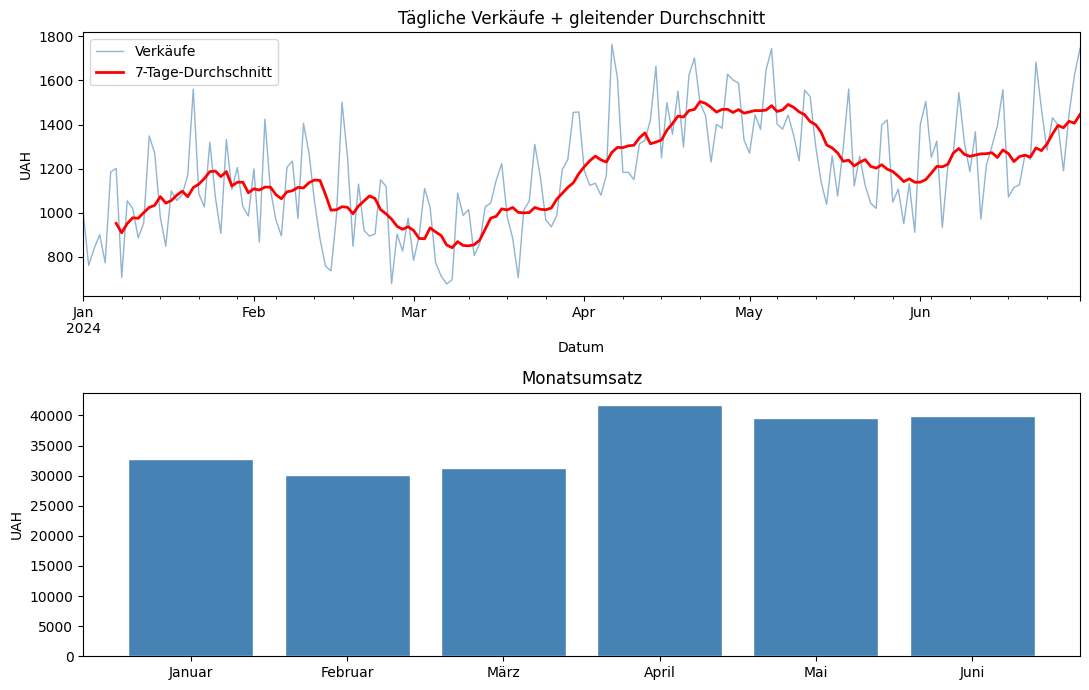

In [47]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7))

# Tägliche Verkäufe + gleitender Durchschnitt
ts['Verkäufe'].plot(ax=axes[0], color='steelblue', alpha=0.6, linewidth=1)
ts['Verkäufe'].rolling(7).mean().plot(
    ax=axes[0], color='red', linewidth=2, label='7-Tage-Durchschnitt'
)
axes[0].set_title('Tägliche Verkäufe + gleitender Durchschnitt')
axes[0].set_ylabel('UAH')
axes[0].legend()

# Monatsumsatz
month_labels = ['Januar','Februar','März','April','Mai','Juni']
axes[1].bar(range(len(monthly)), monthly.values, color='steelblue', edgecolor='white')
axes[1].set_xticks(range(len(monthly)))
axes[1].set_xticklabels(month_labels)
axes[1].set_title('Monatsumsatz')
axes[1].set_ylabel('UAH')

plt.tight_layout()
plt.show()


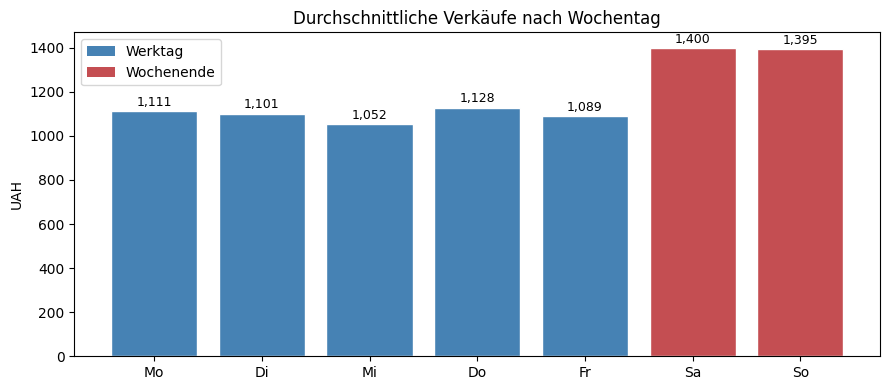

In [48]:
# Durchschnittliche Verkäufe nach Wochentag
days_de = ['Mo','Di','Mi','Do','Fr','Sa','So']
avg_by_weekday = ts_ext.groupby('Wochentag')['Verkäufe'].mean().round(0)

colors = ['#C44E52' if i >= 5 else 'steelblue' for i in range(7)]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(days_de, avg_by_weekday.values, color=colors, edgecolor='white')
ax.set_title('Durchschnittliche Verkäufe nach Wochentag')
ax.set_ylabel('UAH')

for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 10,
            f'{h:,.0f}', ha='center', va='bottom', fontsize=9)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='steelblue', label='Werktag'),
                   Patch(facecolor='#C44E52',   label='Wochenende')])
plt.tight_layout()
plt.show()


### 🎯 Aufgabe 7.1

Verwende `ts`:
1. Finde den Tag mit den maximalen und minimalen Verkäufen
2. Berechne die durchschnittlichen Verkäufe nach Monaten (`resample('ME').mean()`)
3. Erstelle ein Liniendiagramm der monatlichen Durchschnitte


In [49]:
# Dein Code hier:




In [50]:
# 💡 Tipp:
print("""
print('Maximum:', ts['Verkäufe'].idxmax(), ts['Verkäufe'].max())
print('Minimum: ', ts['Verkäufe'].idxmin(), ts['Verkäufe'].min())

monthly_avg = ts.resample('ME')['Verkäufe'].mean().round(0)
print(monthly_avg)

monthly_avg.plot(kind='line', marker='o', color='steelblue', linewidth=2,
                 title='Durchschnittlicher Tagesverkauf nach Monaten', ylabel='UAH')
plt.tight_layout()
plt.show()
""")



print('Maximum:', ts['Verkäufe'].idxmax(), ts['Verkäufe'].max())
print('Minimum: ', ts['Verkäufe'].idxmin(), ts['Verkäufe'].min())

monthly_avg = ts.resample('ME')['Verkäufe'].mean().round(0)
print(monthly_avg)

monthly_avg.plot(kind='line', marker='o', color='steelblue', linewidth=2,
                 title='Durchschnittlicher Tagesverkauf nach Monaten', ylabel='UAH')
plt.tight_layout()
plt.show()



---
## 🏆 Abschlussprojekt — Analysebericht

Du bist Junior-Datenanalyst in einem Online-Shop.
Dein Vorgesetzter bittet dich, einen **Monatsbericht** für die erste Hälfte 2024 vorzubereiten.


In [51]:
# Erzeugung des finalen Datensatzes
np.random.seed(2024)
N = 500

dates_full  = pd.date_range('2024-01-01', '2024-06-30', freq='D')
order_dates = np.random.choice(dates_full, N)

final = pd.DataFrame({
    'Datum':      pd.to_datetime(order_dates),
    'Kunden_ID':  np.random.randint(1001, 1200, N),
    'Kategorie':  np.random.choice(['Elektronik','Kleidung','Bücher','Sport','Haus'], N,
                                    p=[0.22,0.28,0.18,0.17,0.15]),
    'Stadt':      np.random.choice(['Kyiv','Harkiv','Odesa','Lviv','Dnipro'], N,
                                    p=[0.35,0.20,0.15,0.20,0.10]),
    'Betrag':     (np.random.exponential(700, N) + 200).round(0).astype(int),
    'Menge':      np.random.randint(1, 7, N),
    'Rabatt_%':   np.random.choice([0,5,10,15,20], N, p=[0.45,0.25,0.15,0.10,0.05]),
    'Rückgabe':   np.random.choice([False, True], N, p=[0.92, 0.08])
})

final['Monat']        = final['Datum'].dt.month
final['Monatsname']   = final['Datum'].dt.strftime('%b')
final['Wochenende']   = final['Datum'].dt.dayofweek >= 5
final['Nettobetrag']  = (final['Betrag'] * (1 - final['Rabatt_%'] / 100)).round(0).astype(int)

print(f'Datensatz: {final.shape[0]} Bestellungen')
print(f'Gesamtumsatz: {final["Nettobetrag"].sum():,} UAH')
print(f'Durchschnittlicher Bon: {final["Nettobetrag"].mean():.0f} UAH')
print(f'Rückgaben:        {final["Rückgabe"].sum()} ({final["Rückgabe"].mean()*100:.1f}%)')
final.head(6)


Datensatz: 500 Bestellungen
Gesamtumsatz: 421,449 UAH
Durchschnittlicher Bon: 843 UAH
Rückgaben:        36 (7.2%)


,Datum,Kunden_ID,Kategorie,Stadt,Betrag,Menge,Rabatt_%,Rückgabe,Monat,Monatsname,Wochenende,Nettobetrag
0,2024-05-16,1047,Kleidung,Harkiv,209,3,0,False,5,May,False,209
1,2024-04-06,1105,Bücher,Lviv,573,4,0,False,4,Apr,True,573
2,2024-05-08,1150,Elektronik,Harkiv,1281,6,0,False,5,May,False,1281
3,2024-01-28,1034,Bücher,Kyiv,1416,4,5,False,1,Jan,True,1345
4,2024-02-06,1054,Kleidung,Dnipro,388,3,10,False,2,Feb,False,349
5,2024-02-11,1172,Elektronik,Kyiv,293,2,20,False,2,Feb,True,234


### 🎯 Abschlussaufgabe — Dashboard

Bereite einen Bericht mit folgenden Blöcken vor:

**Block A — Umsatzdynamik**
- Gesamtumsatz nach Monaten
- Umsatz am Wochenende vs an Werktagen

**Block B — Umsatzstruktur**
- Umsatz nach Kategorien (barh)
- Anzahl der Bestellungen nach Städten (bar)

**Block C — Kundenanalyse**
- Verteilung der Bestellbeträge (Histogramm)
- Top-5-Kunden nach Gesamtbetrag (barh)

**Block D — Textliche Schlussfolgerungen:** welcher Monat ist der beste? welche Kategorie? Stadt-Spitzenreiter?


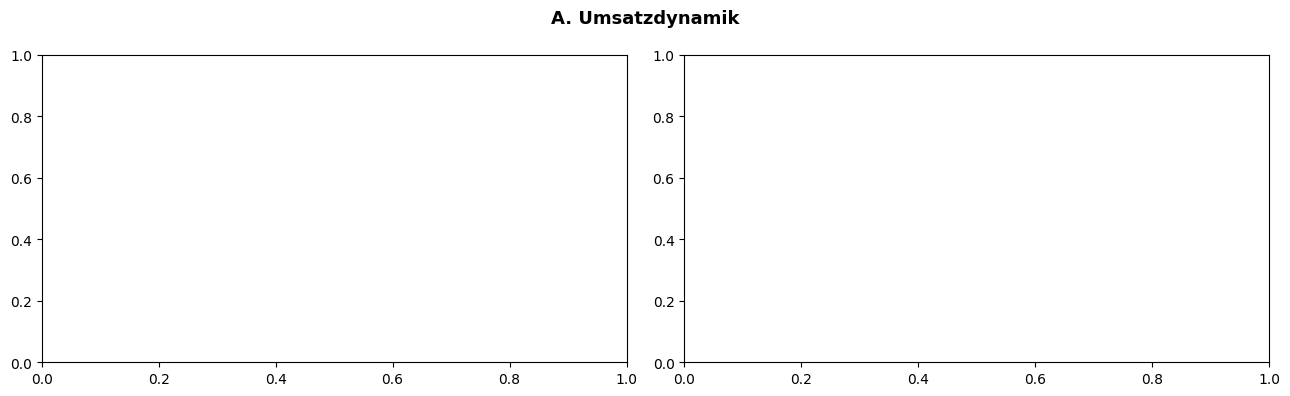

In [52]:
# ═══ BLOCK A — Umsatzdynamik ═══
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('A. Umsatzdynamik', fontsize=13, weight='bold')

# Dein Code hier:

plt.tight_layout()
plt.show()


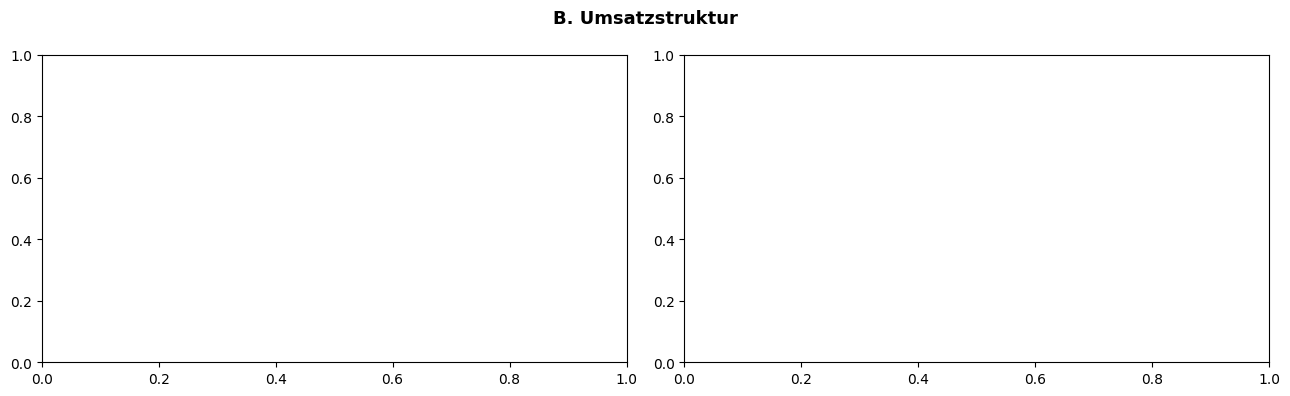

In [53]:
# ═══ BLOCK B — Struktur ═══
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('B. Umsatzstruktur', fontsize=13, weight='bold')

# Dein Code hier:

plt.tight_layout()
plt.show()


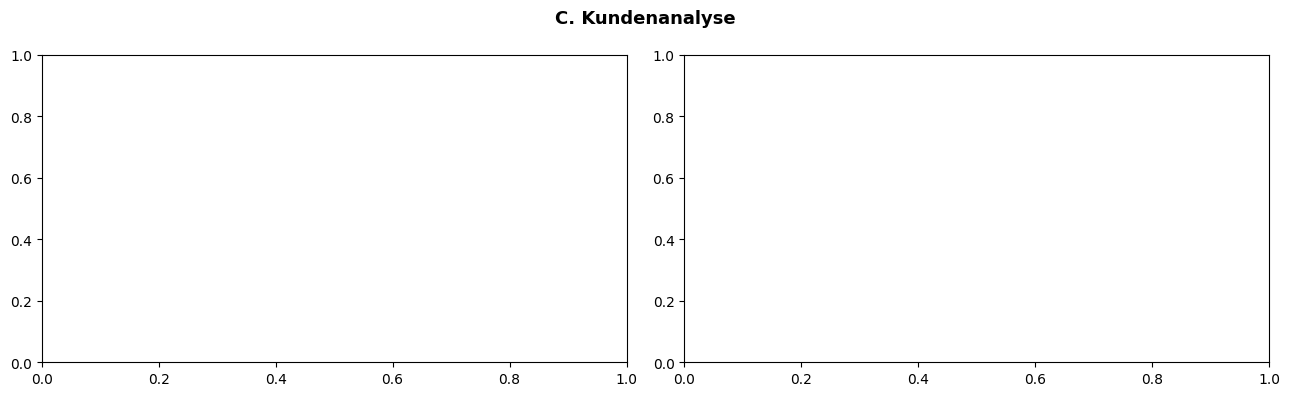

In [54]:
# ═══ BLOCK C — Kunden ═══
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('C. Kundenanalyse', fontsize=13, weight='bold')

# Dein Code hier:

plt.tight_layout()
plt.show()


### D. Schlussfolgerungen

*(Schreibe hier deine Schlussfolgerungen nach der Analyse)*

- **Bester Monat:** ...
- **Profitabelste Kategorie:** ...
- **Stadt-Spitzenreiter:** ...
- **Empfehlungen:** ...


In [55]:
# 💡 Tipp zum Abschlussprojekt:
print("""
# ═══ BLOCK A ═══
month_names = ['Jan','Feb','Mär','Apr','Mai','Jun']
monthly_rev = final.groupby('Monat')['Nettobetrag'].sum()
axes[0].bar(month_names[:len(monthly_rev)], monthly_rev.values,
            color='steelblue', edgecolor='white')
axes[0].set_title('Umsatz nach Monaten')
axes[0].set_ylabel('UAH')

weekend_rev = final.groupby('Wochenende')['Nettobetrag'].sum()
axes[1].bar(['Werktage','Wochenende'], weekend_rev.values,
            color=['steelblue','#C44E52'], edgecolor='white')
axes[1].set_title('Umsatz: Werktage vs Wochenende')

# ═══ BLOCK B ═══
cat_rev = final.groupby('Kategorie')['Nettobetrag'].sum().sort_values()
cat_rev.plot.barh(ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Umsatz nach Kategorien')

city_cnt = final['Stadt'].value_counts()
city_cnt.plot.bar(ax=axes[1], color='mediumseagreen', edgecolor='white', rot=20)
axes[1].set_title('Bestellungen nach Städten')

# ═══ BLOCK C ═══
final['Nettobetrag'].plot.hist(ax=axes[0], bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(final['Nettobetrag'].mean(), color='red', linestyle='--',
                label=f"Durchschnitt: {final['Nettobetrag'].mean():.0f}")
axes[0].set_title('Verteilung der Bestellbeträge')
axes[0].legend()

top5 = final.groupby('Kunden_ID')['Nettobetrag'].sum().nlargest(5)
top5.plot.barh(ax=axes[1], color='#8172B2', edgecolor='white')
axes[1].set_title('Top-5-Kunden')

# ═══ SCHLUSSFOLGERUNGEN ═══
print('Bester Monat:              ', final.groupby('Monat')['Nettobetrag'].sum().idxmax())
print('Profitabelste Kategorie:   ', final.groupby('Kategorie')['Nettobetrag'].sum().idxmax())
print('Stadt-Spitzenreiter:       ', final['Stadt'].value_counts().idxmax())
""")



# ═══ BLOCK A ═══
month_names = ['Jan','Feb','Mär','Apr','Mai','Jun']
monthly_rev = final.groupby('Monat')['Nettobetrag'].sum()
axes[0].bar(month_names[:len(monthly_rev)], monthly_rev.values,
            color='steelblue', edgecolor='white')
axes[0].set_title('Umsatz nach Monaten')
axes[0].set_ylabel('UAH')

weekend_rev = final.groupby('Wochenende')['Nettobetrag'].sum()
axes[1].bar(['Werktage','Wochenende'], weekend_rev.values,
            color=['steelblue','#C44E52'], edgecolor='white')
axes[1].set_title('Umsatz: Werktage vs Wochenende')

# ═══ BLOCK B ═══
cat_rev = final.groupby('Kategorie')['Nettobetrag'].sum().sort_values()
cat_rev.plot.barh(ax=axes[0], color='coral', edgecolor='white')
axes[0].set_title('Umsatz nach Kategorien')

city_cnt = final['Stadt'].value_counts()
city_cnt.plot.bar(ax=axes[1], color='mediumseagreen', edgecolor='white', rot=20)
axes[1].set_title('Bestellungen nach Städten')

# ═══ BLOCK C ═══
final['Nettobetrag'].plot.hist(ax=axes[0], bins=30, color='steelb

---
## 📋 Spickzettel — Pandas + Matplotlib zusammen

### Grundlegende Pandas-Operationen

| Was tun | Code |
|-----------|-----|
| Tabelle erstellen | `pd.DataFrame({'col': [1,2,3]})` |
| Größe | `df.shape` |
| Erste Zeilen | `df.head(5)` |
| Statistik | `df.describe()` |
| Spalte auswählen | `df['col']` |
| Mehrere auswählen | `df[['col1','col2']]` |
| Filter | `df[df['col'] > 5]` |
| Komplexer Filter | `df[(df['a'] > 1) & (df['b'] == 'X')]` |
| Neue Spalte | `df['new'] = df['a'] * 2` |
| Bedingte Spalte | `np.where(Bedingung, wenn_ja, wenn_nein)` |
| Gruppieren | `df.groupby('col')['val'].sum()` |
| Sortieren | `df.sort_values('col', ascending=False)` |
| Top-N | `df.nlargest(5, 'col')` |
| Häufigkeit | `df['col'].value_counts()` |
| Fehlende Werte | `df.isnull().sum()` |
| NaN auffüllen | `df['col'].fillna(0)` |
| Resampling | `df.resample('ME').sum()` |

### Diagrammtypen und wann man sie verwendet

| Typ | Code | Wann |
|-----|-----|------|
| Linie | `.plot(kind='line')` | Zeitliche Entwicklung |
| Balken | `.plot(kind='bar')` | Vergleich von Kategorien |
| Horizontal | `.plot(kind='barh')` | Rankings, lange Beschriftungen |
| Kreis | `.plot(kind='pie')` | Anteile (bis ~5 Segmente) |
| Histogramm | `.plot(kind='hist')` | Verteilung numerischer Daten |
| Scatter | `.plot(kind='scatter', x=, y=)` | Zusammenhang zweier Variablen |
| Mehrere | `fig, axes = plt.subplots(r, c)` | Dashboard |

### Formel: groupby → Diagramm
```python
result = df.groupby('Kategorie')['Wert'].sum()  # 1. berechnen
result.plot.bar(title='...', ylabel='...', edgecolor='white')  # 2. zeichnen
plt.tight_layout()
plt.show()
```

---
## Wie geht es weiter?
- **Seaborn** — schönere statistische Visualisierung
- **Pandas advanced** — `merge`, `pivot_table`, `apply`
- **Plotly** — interaktive Diagramme
- **Scikit-learn** — maschinelles Lernen
